In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.signal import convolve

In [6]:
import os
import numpy as np
from scipy.io import wavfile
import librosa # Added librosa for MP3 support

song1_path = r"/content/prajwal.mp3"

song2_path = r"/content/prajwal.mp3"

song3_path = r"/content/prajwal.mp3"

for file in [song1_path, song2_path, song3_path]:

    if not os.path.exists(file):
        print(file)
        raise FileNotFoundError("Audio file not found.")

print("All Audio Files Found Successfully.")

# Using librosa.load to read MP3 files
song1, fs1 = librosa.load(song1_path, sr=None) # sr=None preserves original sampling rate
song2, fs2 = librosa.load(song2_path, sr=None)
song3, fs3 = librosa.load(song3_path, sr=None)

# librosa.load automatically converts to mono and loads as float, so no need for explicit .ndim check or initial astype

song1 = song1.astype(np.float32)
song2 = song2.astype(np.float32)
song3 = song3.astype(np.float32)

song1 = song1 / np.max(np.abs(song1))
song2 = song2 / np.max(np.abs(song2))
song3 = song3 / np.max(np.abs(song3))

minimum = min(
    len(song1),
    len(song2),
    len(song3)
)

song1 = song1[:minimum]
song2 = song2[:minimum]
song3 = song3[:minimum]

print("Sampling Rate :", fs1)
print("Common Samples :", minimum)

audio_folder = "Processed_Audio"
graph_folder = "Comparison_Graphs"

os.makedirs(audio_folder, exist_ok=True)
os.makedirs(graph_folder, exist_ok=True)

print("Output folders created successfully.")

All Audio Files Found Successfully.
Sampling Rate : 44100
Common Samples : 5647360
Output folders created successfully.


In [7]:
# 1. Identity
ir1 = np.array([1.0])

# 2. Noise Reduction (Moving Average)
ir2 = np.ones(5) / 5

# 3. Low Pass Filter
ir3 = np.array([
    0.25,
    0.50,
    0.25
])

# 4. High Pass Filter
ir4 = np.array([
    -1,
     2,
    -1
])

# 5. Edge Detection
ir5 = np.array([
     1,
     0,
    -1
])

# 6. Sharpen
ir6 = np.array([
    -0.5,
     2.0,
    -0.5
])

# 7. Room Reverb
ir7 = np.array([
    1.0,
    0.6,
    0.3,
    0.15
])

# 8. Hall Reverb
ir8 = np.exp(
    -np.linspace(
        0,
        2,
        25
    )
)

# 9. Echo
ir9 = np.zeros(30)

ir9[0] = 1.0
ir9[10] = 0.6
ir9[20] = 0.4

# 10. Exponential Decay
ir10 = np.exp(
    -np.linspace(
        0,
        3,
        15
    )
)

impulse_responses = {

    "Identity"       : ir1,
    "NoiseReduction" : ir2,
    "LowPass"        : ir3,
    "HighPass"       : ir4,
    "EdgeDetection"  : ir5,
    "Sharpen"        : ir6,
    "RoomReverb"     : ir7,
    "HallReverb"     : ir8,
    "Echo"           : ir9,
    "Decay"          : ir10
}

print("Total Impulse Responses :", len(impulse_responses))
print("\nImpulse Responses")

for name in impulse_responses:
    print(name)

Total Impulse Responses : 10

Impulse Responses
Identity
NoiseReduction
LowPass
HighPass
EdgeDetection
Sharpen
RoomReverb
HallReverb
Echo
Decay


In [8]:
original_outputs = {}

for name, ir in impulse_responses.items():

    output = convolve(song1, ir, mode="same")

    output = output / np.max(np.abs(output))

    original_outputs[name] = output

    wavfile.write(
        os.path.join(
            audio_folder,
            f"Original_{name}.wav"
        ),
        fs1,
        (output * 32767).astype(np.int16)
    )

print("Original Song Processing Completed")

print("Generated Files")

for name in impulse_responses.keys():
    print(f"Original_{name}.wav")

Original Song Processing Completed
Generated Files
Original_Identity.wav
Original_NoiseReduction.wav
Original_LowPass.wav
Original_HighPass.wav
Original_EdgeDetection.wav
Original_Sharpen.wav
Original_RoomReverb.wav
Original_HallReverb.wav
Original_Echo.wav
Original_Decay.wav


In [9]:
karaoke_outputs = {}

for name, ir in impulse_responses.items():

    output = convolve(song2, ir, mode="same")

    output = output / np.max(np.abs(output))

    karaoke_outputs[name] = output

    wavfile.write(
        os.path.join(
            audio_folder,
            f"Karaoke_{name}.wav"
        ),
        fs2,
        (output * 32767).astype(np.int16)
    )

print("Karaoke Song Processing Completed")

print("Generated Files")

for name in impulse_responses.keys():
    print(f"Karaoke_{name}.wav")

Karaoke Song Processing Completed
Generated Files
Karaoke_Identity.wav
Karaoke_NoiseReduction.wav
Karaoke_LowPass.wav
Karaoke_HighPass.wav
Karaoke_EdgeDetection.wav
Karaoke_Sharpen.wav
Karaoke_RoomReverb.wav
Karaoke_HallReverb.wav
Karaoke_Echo.wav
Karaoke_Decay.wav


In [10]:
different_outputs = {}

for name, ir in impulse_responses.items():

    output = convolve(song3, ir, mode="same")

    output = output / np.max(np.abs(output))

    different_outputs[name] = output

    wavfile.write(
        os.path.join(
            audio_folder,
            f"Different_{name}.wav"
        ),
        fs3,
        (output * 32767).astype(np.int16)
    )

print("Different Song Processing Completed")

print("Generated Files")

for name in impulse_responses.keys():
    print(f"Different_{name}.wav")

Different Song Processing Completed
Generated Files
Different_Identity.wav
Different_NoiseReduction.wav
Different_LowPass.wav
Different_HighPass.wav
Different_EdgeDetection.wav
Different_Sharpen.wav
Different_RoomReverb.wav
Different_HallReverb.wav
Different_Echo.wav
Different_Decay.wav


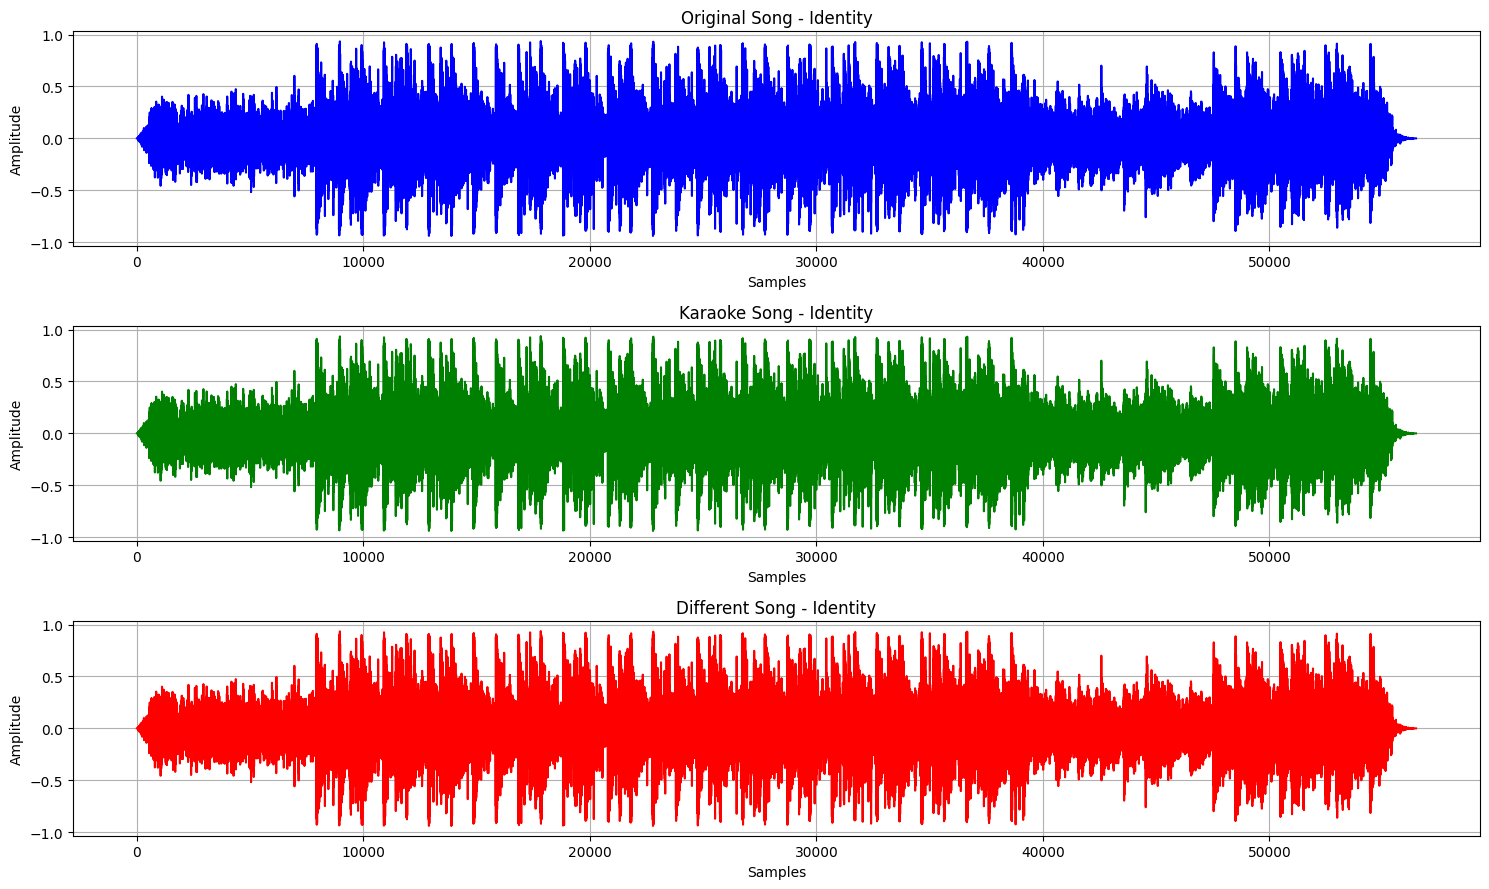

Identity Comparison Saved


In [11]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["Identity"][::100], color="blue")
plt.title("Original Song - Identity")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["Identity"][::100], color="green")
plt.title("Karaoke Song - Identity")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["Identity"][::100], color="red")
plt.title("Different Song - Identity")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Identity_Comparison.png"
    )
)

plt.show()

print("Identity Comparison Saved")

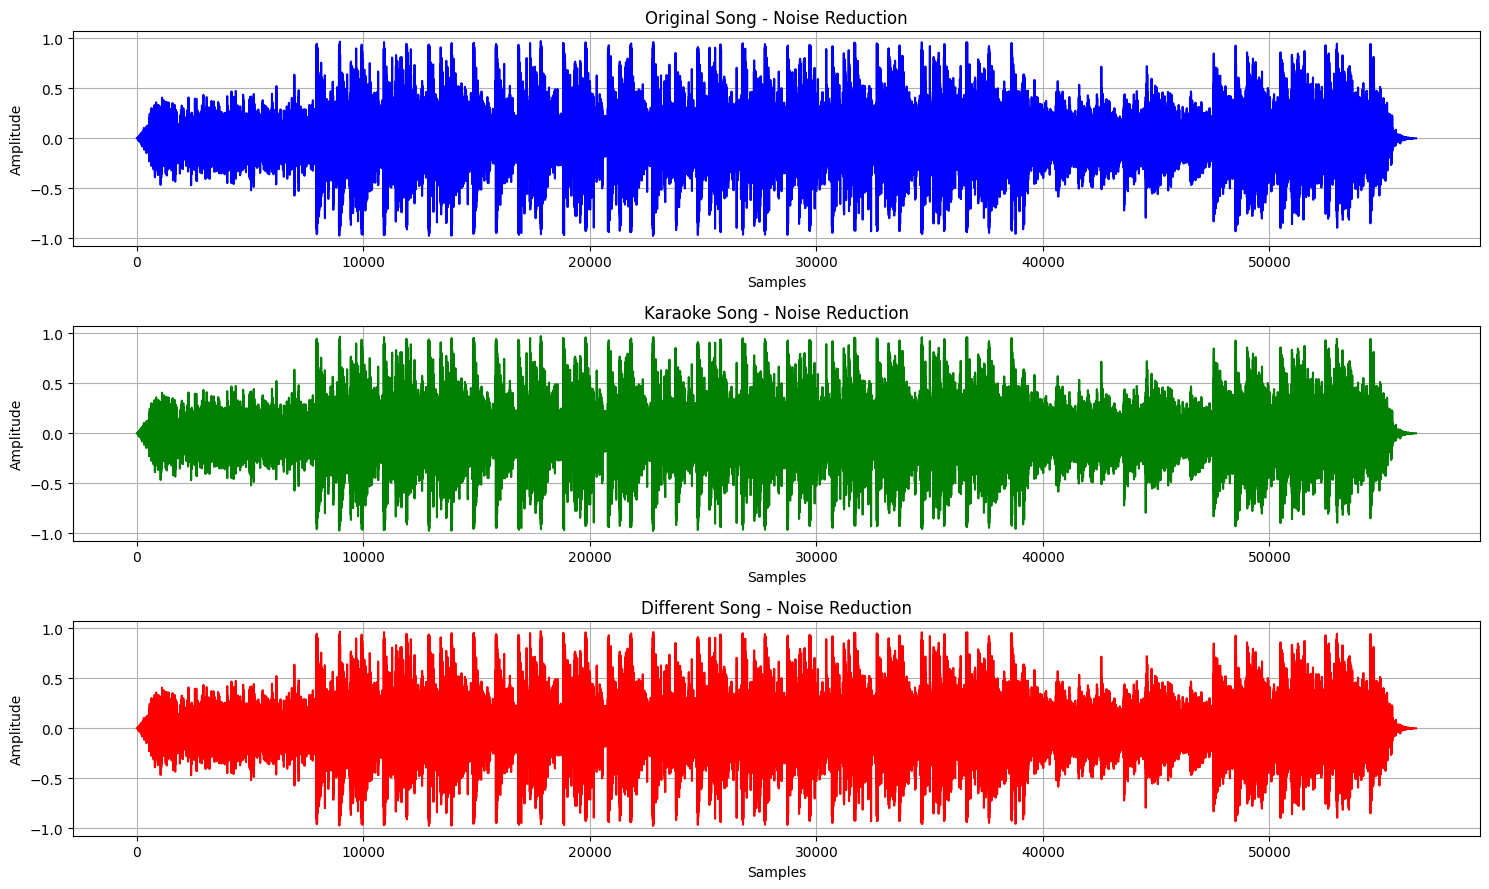

Noise Reduction Comparison Saved


In [12]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["NoiseReduction"][::100], color="blue")
plt.title("Original Song - Noise Reduction")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["NoiseReduction"][::100], color="green")
plt.title("Karaoke Song - Noise Reduction")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["NoiseReduction"][::100], color="red")
plt.title("Different Song - Noise Reduction")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "NoiseReduction_Comparison.png"
    )
)

plt.show()

print("Noise Reduction Comparison Saved")

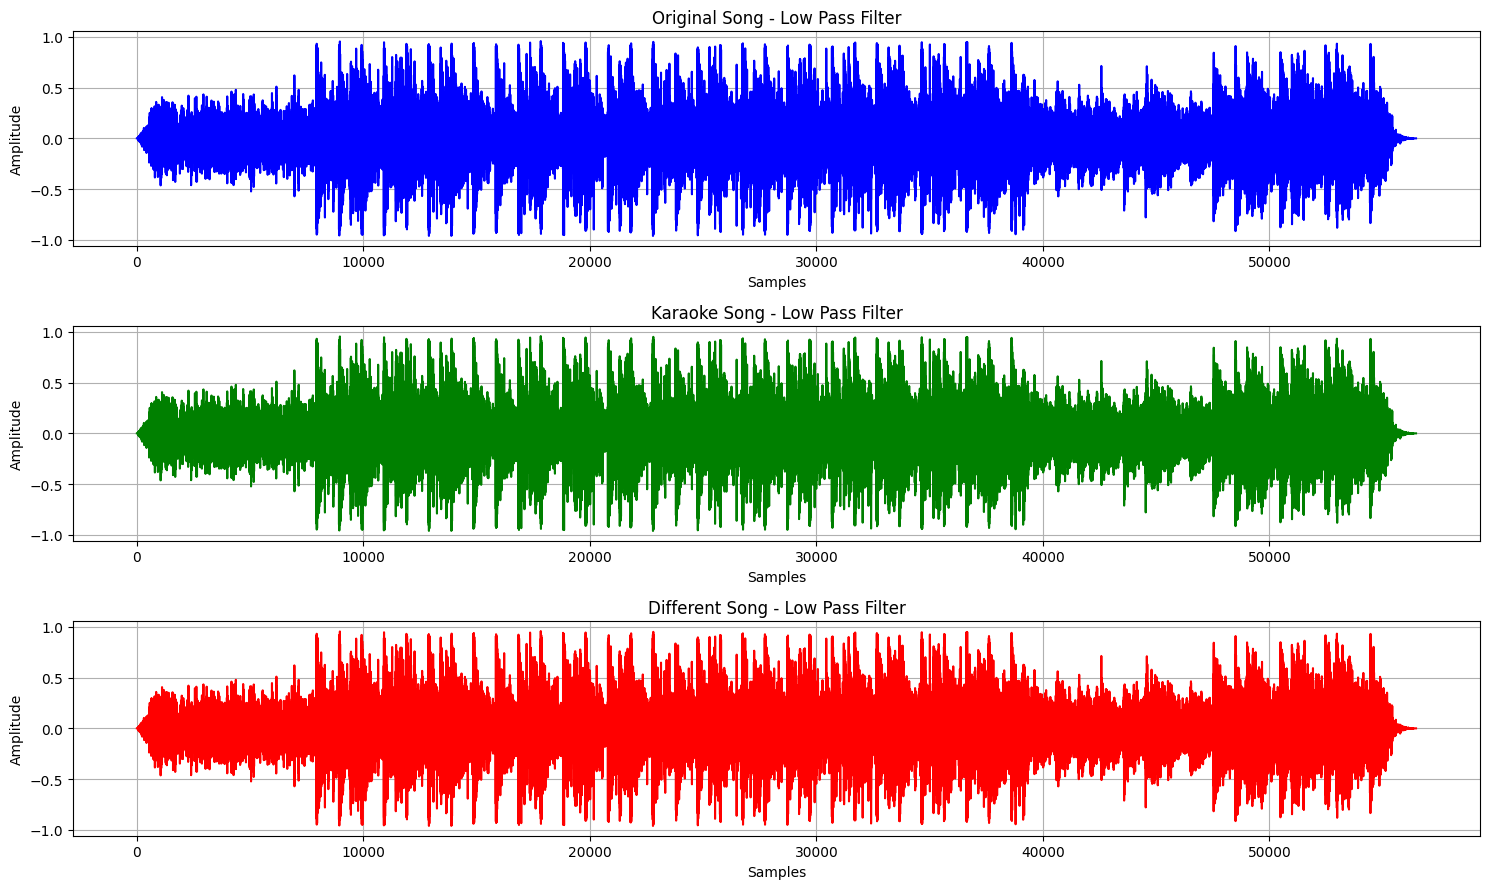

Low Pass Comparison Saved


In [13]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["LowPass"][::100], color="blue")
plt.title("Original Song - Low Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["LowPass"][::100], color="green")
plt.title("Karaoke Song - Low Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["LowPass"][::100], color="red")
plt.title("Different Song - Low Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "LowPass_Comparison.png"
    )
)

plt.show()

print("Low Pass Comparison Saved")

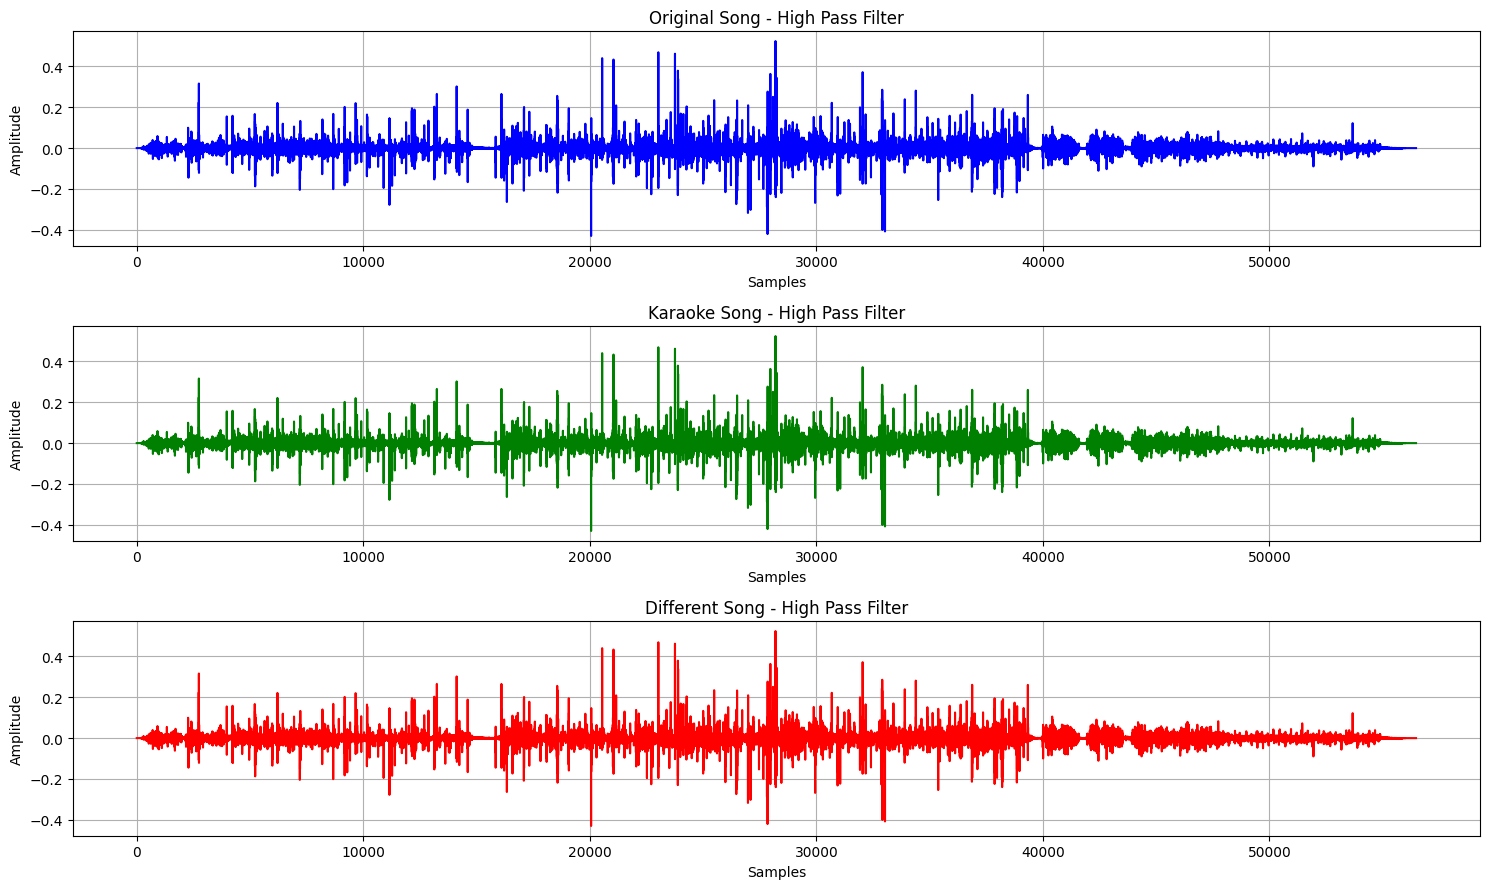

High Pass Comparison Saved


In [14]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["HighPass"][::100], color="blue")
plt.title("Original Song - High Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["HighPass"][::100], color="green")
plt.title("Karaoke Song - High Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["HighPass"][::100], color="red")
plt.title("Different Song - High Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "HighPass_Comparison.png"
    )
)

plt.show()

print("High Pass Comparison Saved")

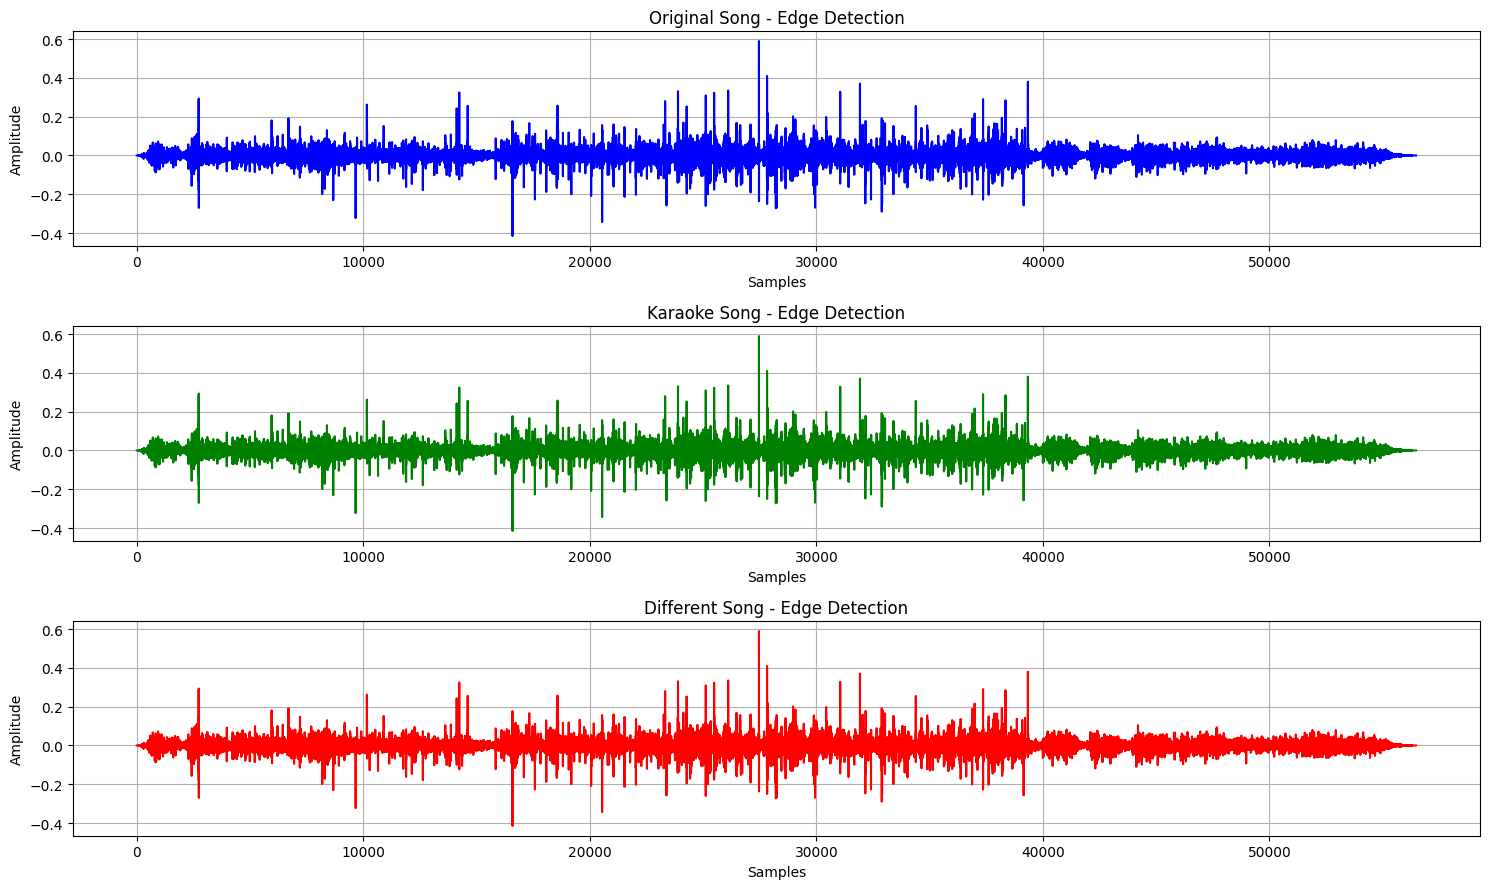

Edge Detection Comparison Saved


In [15]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["EdgeDetection"][::100], color="blue")
plt.title("Original Song - Edge Detection")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["EdgeDetection"][::100], color="green")
plt.title("Karaoke Song - Edge Detection")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["EdgeDetection"][::100], color="red")
plt.title("Different Song - Edge Detection")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "EdgeDetection_Comparison.png"
    )
)

plt.show()

print("Edge Detection Comparison Saved")

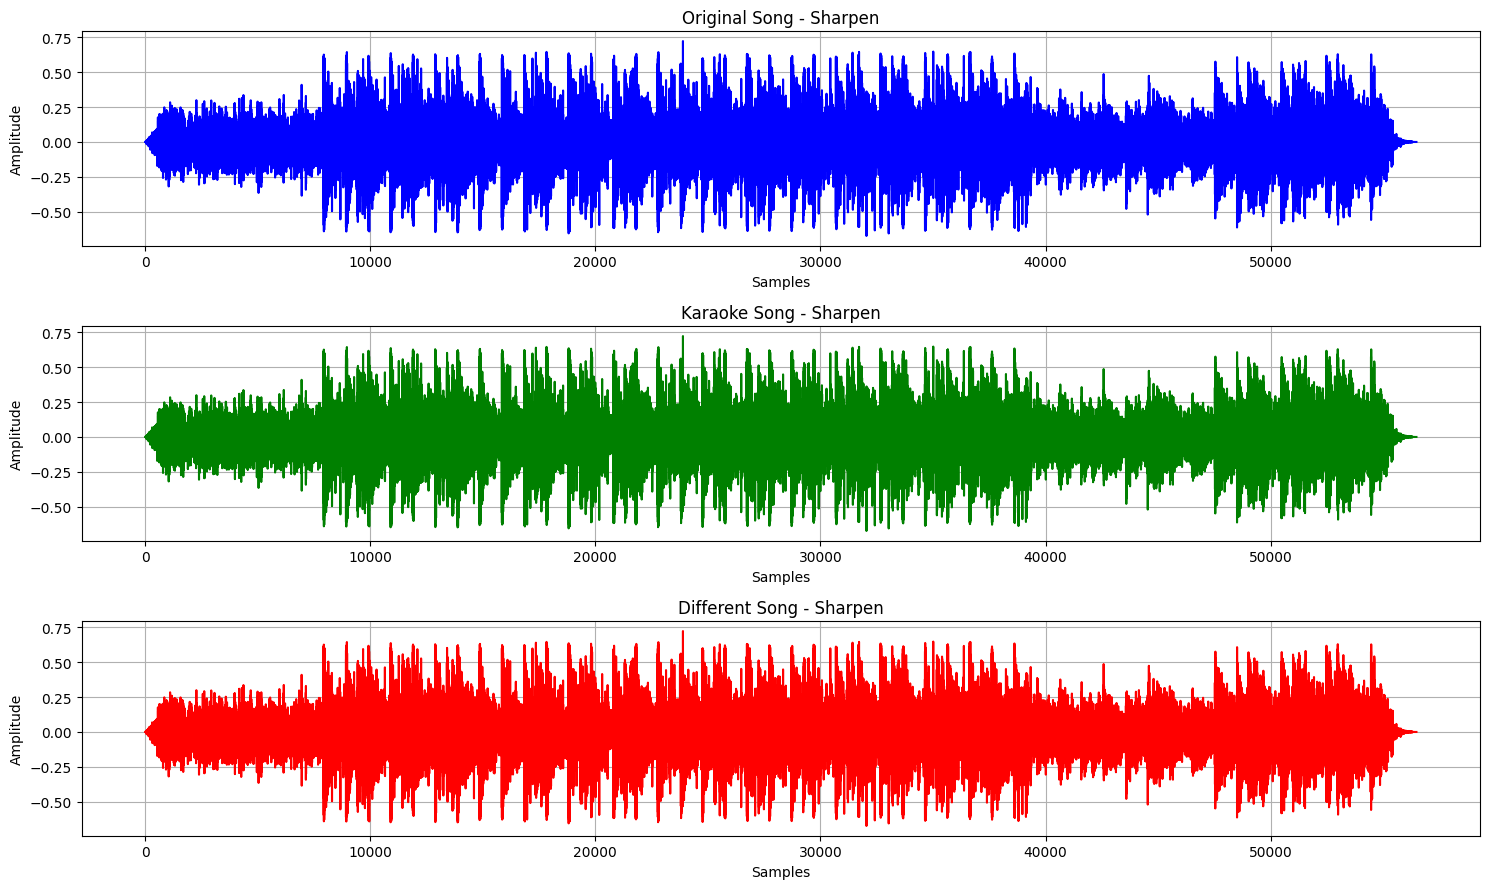

Sharpen Comparison Saved


In [16]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["Sharpen"][::100], color="blue")
plt.title("Original Song - Sharpen")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["Sharpen"][::100], color="green")
plt.title("Karaoke Song - Sharpen")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["Sharpen"][::100], color="red")
plt.title("Different Song - Sharpen")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Sharpen_Comparison.png"
    )
)

plt.show()

print("Sharpen Comparison Saved")

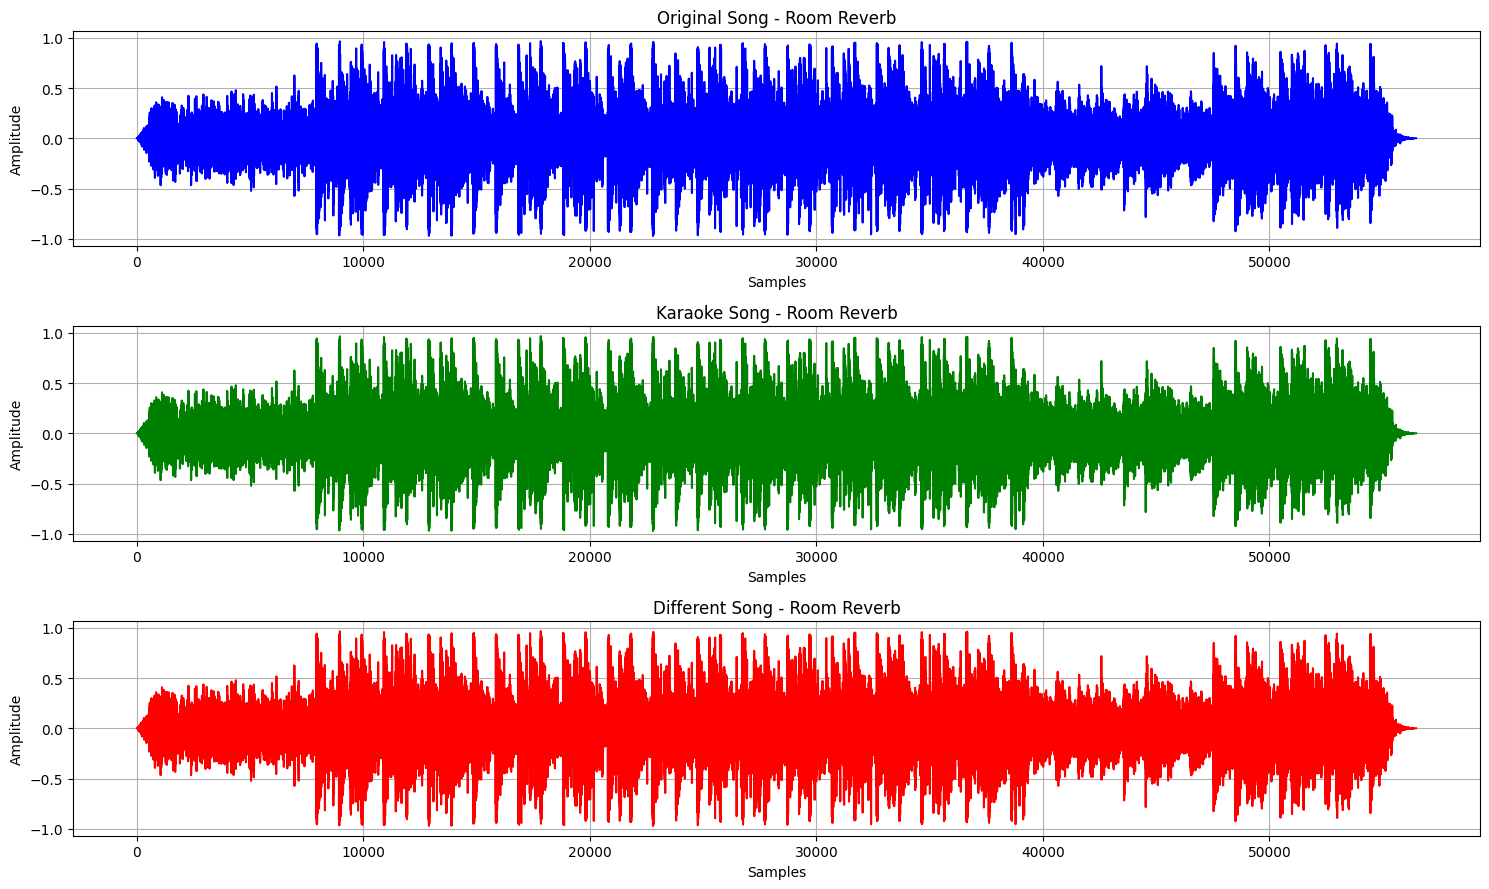

Room Reverb Comparison Saved


In [17]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["RoomReverb"][::100], color="blue")
plt.title("Original Song - Room Reverb")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["RoomReverb"][::100], color="green")
plt.title("Karaoke Song - Room Reverb")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["RoomReverb"][::100], color="red")
plt.title("Different Song - Room Reverb")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "RoomReverb_Comparison.png"
    )
)

plt.show()

print("Room Reverb Comparison Saved")

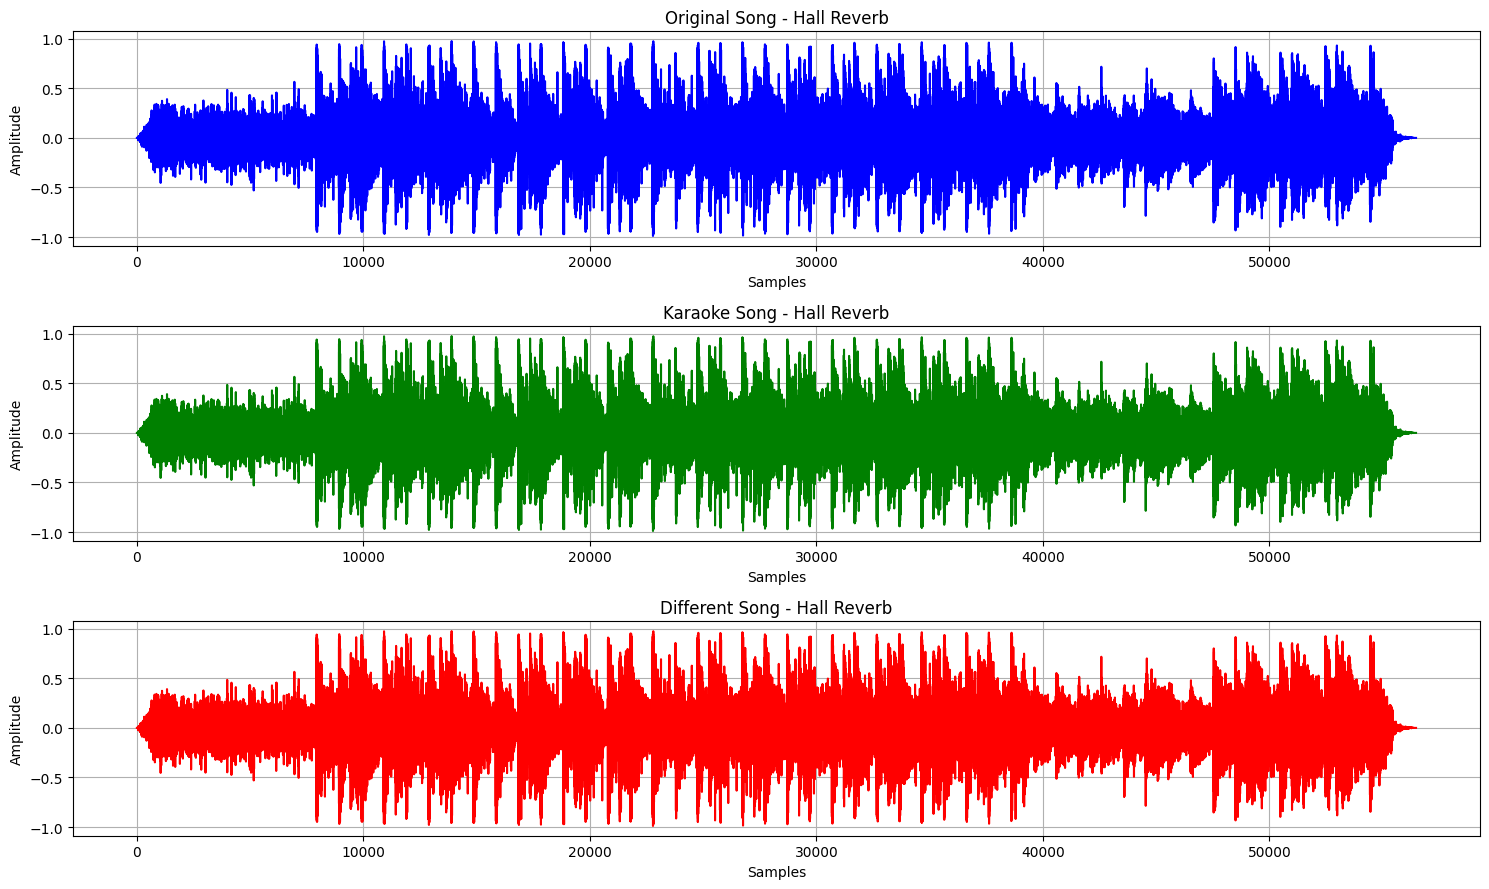

Hall Reverb Comparison Saved


In [18]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["HallReverb"][::100], color="blue")
plt.title("Original Song - Hall Reverb")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["HallReverb"][::100], color="green")
plt.title("Karaoke Song - Hall Reverb")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["HallReverb"][::100], color="red")
plt.title("Different Song - Hall Reverb")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "HallReverb_Comparison.png"
    )
)

plt.show()

print("Hall Reverb Comparison Saved")

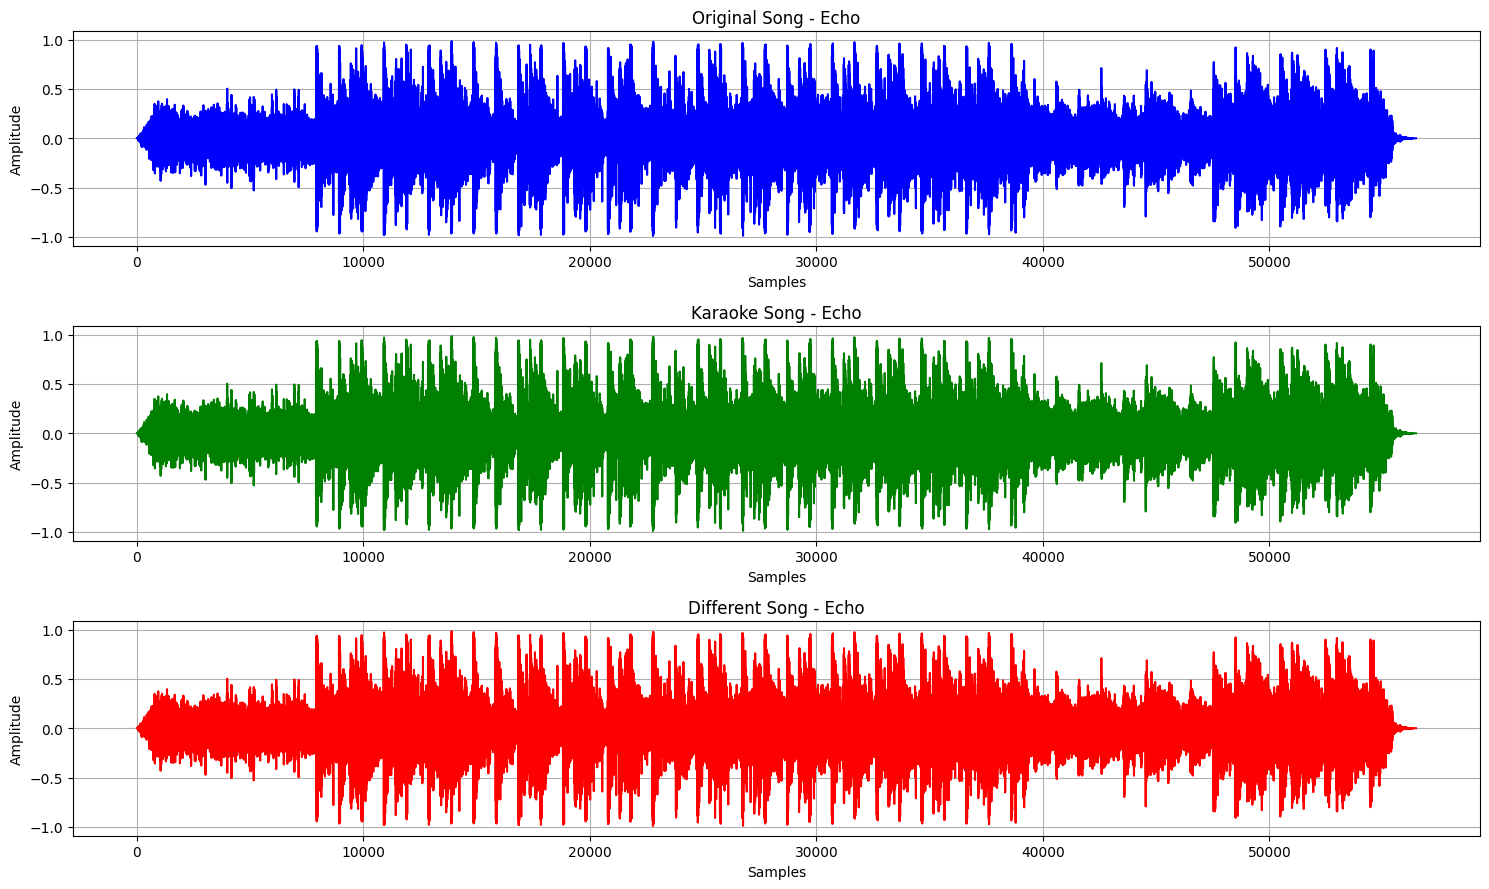

Echo Comparison Saved


In [19]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["Echo"][::100], color="blue")
plt.title("Original Song - Echo")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["Echo"][::100], color="green")
plt.title("Karaoke Song - Echo")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["Echo"][::100], color="red")
plt.title("Different Song - Echo")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Echo_Comparison.png"
    )
)

plt.show()

print("Echo Comparison Saved")

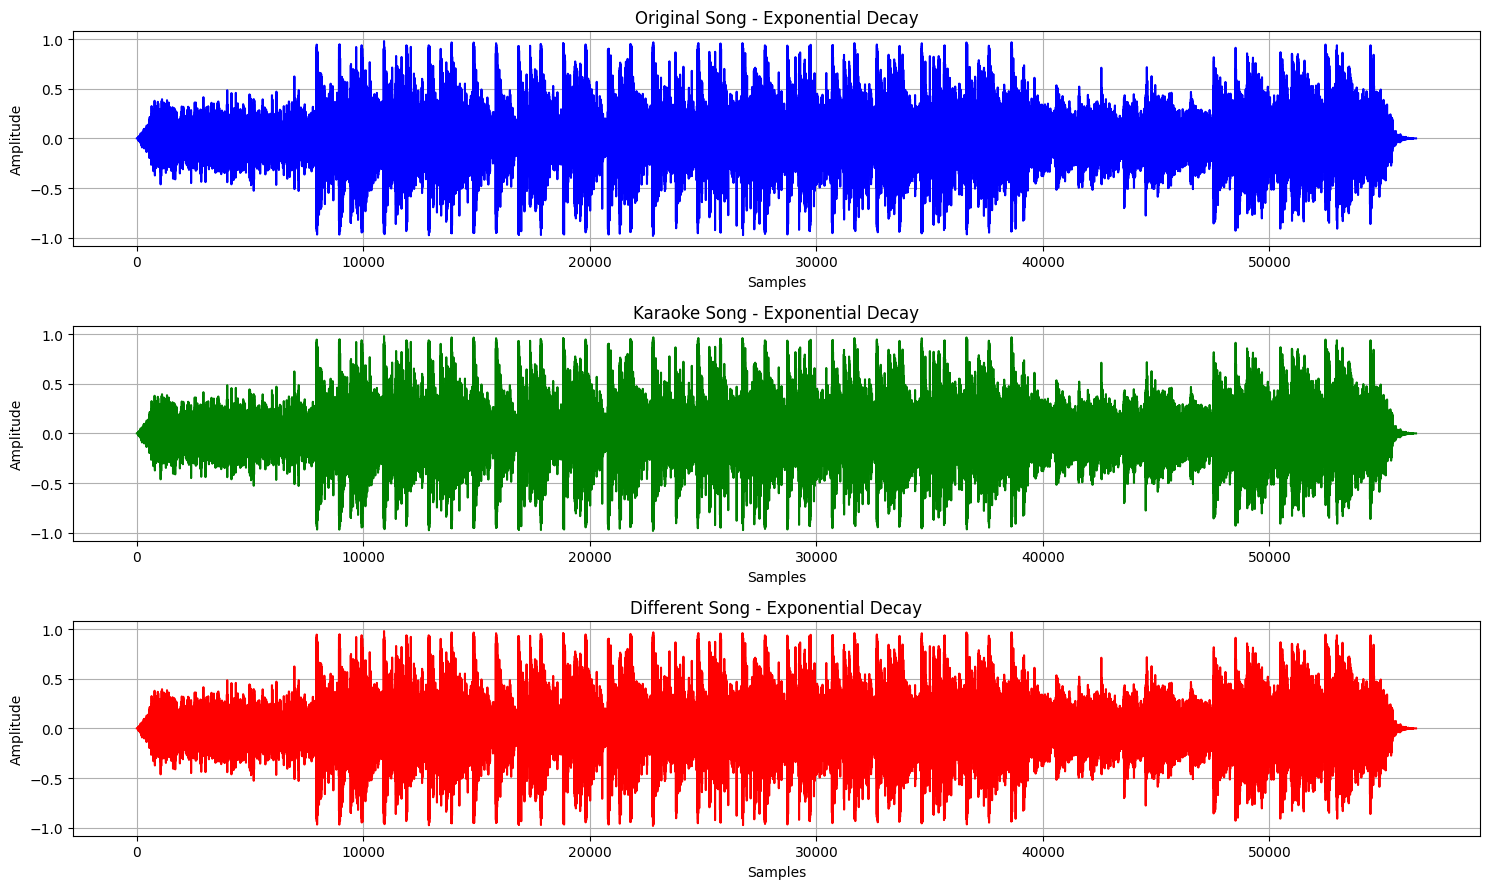

Exponential Decay Comparison Saved


In [20]:
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(original_outputs["Decay"][::100], color="blue")
plt.title("Original Song - Exponential Decay")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(karaoke_outputs["Decay"][::100], color="green")
plt.title("Karaoke Song - Exponential Decay")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(different_outputs["Decay"][::100], color="red")
plt.title("Different Song - Exponential Decay")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Decay_Comparison.png"
    )
)

plt.show()

print("Exponential Decay Comparison Saved")

In [21]:
print("PROCESS COMPLETED SUCCESSFULLY")

print("\nGenerated Audio Files")

for name in impulse_responses.keys():

    print(f"Original_{name}.wav")
    print(f"Karaoke_{name}.wav")
    print(f"Different_{name}.wav")

print("\nGenerated Comparison Images")

print("Identity_Comparison.png")
print("NoiseReduction_Comparison.png")
print("LowPass_Comparison.png")
print("HighPass_Comparison.png")
print("EdgeDetection_Comparison.png")
print("Sharpen_Comparison.png")
print("RoomReverb_Comparison.png")
print("HallReverb_Comparison.png")
print("Echo_Comparison.png")
print("Decay_Comparison.png")

print("\nTotal Audio Files :", 30)
print("Total Comparison Images :", 10)

print("\nAudio Folder :", os.path.abspath(audio_folder))
print("Graph Folder :", os.path.abspath(graph_folder))

PROCESS COMPLETED SUCCESSFULLY

Generated Audio Files
Original_Identity.wav
Karaoke_Identity.wav
Different_Identity.wav
Original_NoiseReduction.wav
Karaoke_NoiseReduction.wav
Different_NoiseReduction.wav
Original_LowPass.wav
Karaoke_LowPass.wav
Different_LowPass.wav
Original_HighPass.wav
Karaoke_HighPass.wav
Different_HighPass.wav
Original_EdgeDetection.wav
Karaoke_EdgeDetection.wav
Different_EdgeDetection.wav
Original_Sharpen.wav
Karaoke_Sharpen.wav
Different_Sharpen.wav
Original_RoomReverb.wav
Karaoke_RoomReverb.wav
Different_RoomReverb.wav
Original_HallReverb.wav
Karaoke_HallReverb.wav
Different_HallReverb.wav
Original_Echo.wav
Karaoke_Echo.wav
Different_Echo.wav
Original_Decay.wav
Karaoke_Decay.wav
Different_Decay.wav

Generated Comparison Images
Identity_Comparison.png
NoiseReduction_Comparison.png
LowPass_Comparison.png
HighPass_Comparison.png
EdgeDetection_Comparison.png
Sharpen_Comparison.png
RoomReverb_Comparison.png
HallReverb_Comparison.png
Echo_Comparison.png
Decay_Comparis